In [ ]:
!pip3 install pyspark

In [7]:
#initialize SparkSession and installed Required Libraries
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Initialize SparkSession
spark = SparkSession.builder \
                    .appName("LinearRegression_spark") \
                    .master("local[*]") \
                    .config("spark.executor.memory", "4g") \
                    .config("spark.driver.memory", "2g") \
                    .config("spark.executor.cores", "2") \
                    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
                    .getOrCreate()


spark

In [8]:
print(f"Spark UI available at: {spark.sparkContext.uiWebUrl}")

Spark UI available at: http://ab54041c29e6:4040


In [9]:
spark.sparkContext.setLogLevel("INFO")

In [10]:
import psutil
print(f"CPU Usage: {psutil.cpu_percent()}%")
print(f"Memory Usage: {psutil.virtual_memory().percent}%")

CPU Usage: 16.2%
Memory Usage: 12.6%


In [11]:
# Load the data from a CSV file
df = spark.read.csv("/content/property.csv", header=True, inferSchema=True)

# get familiar with data
df.show()

# more info
print("Total Records",df.count())
print("Total Partitions ",df.rdd.getNumPartitions())

+--------------+------------+-------------+----------+--------+------------------+
|Square_Footage|Num_Bedrooms|Num_Bathrooms|Year_Built|Lot_Size|             Price|
+--------------+------------+-------------+----------+--------+------------------+
|          1360|           2|            3|      1953|    7860| 303948.1373854071|
|          4272|           3|            3|      1997|    5292| 860386.2685075302|
|          3592|           4|            1|      1983|    9723| 734389.7538956215|
|           966|           6|            1|      1903|    4086| 226448.8070714377|
|          4926|           6|            4|      1944|    1081|1022486.2616704078|
|          3944|           6|            2|      1938|    3542| 845638.1354384426|
|          3671|           2|            1|      1963|    5105| 748779.2192281872|
|          3419|           4|            2|      1925|    5448| 743007.2614135538|
|           630|           2|            2|      2012|    3204| 135656.4528785377|
|   

In [12]:
df.printSchema()

root
 |-- Square_Footage: integer (nullable = true)
 |-- Num_Bedrooms: integer (nullable = true)
 |-- Num_Bathrooms: integer (nullable = true)
 |-- Year_Built: integer (nullable = true)
 |-- Lot_Size: integer (nullable = true)
 |-- Price: double (nullable = true)



In [13]:
df.describe().show()

+-------+-----------------+-----------------+------------------+-----------------+-----------------+------------------+
|summary|   Square_Footage|     Num_Bedrooms|     Num_Bathrooms|       Year_Built|         Lot_Size|             Price|
+-------+-----------------+-----------------+------------------+-----------------+-----------------+------------------+
|  count|          1000000|          1000000|           1000000|          1000000|          1000000|           1000000|
|   mean|      2750.657104|         3.501114|          2.500439|       1960.52736|      5502.373911| 581839.6653163614|
| stddev|1298.569362387213|1.708173784151257|1.1178528780094728|35.21780350510348|2598.885882999355|260685.36722644986|
|    min|              500|                1|                 1|             1900|             1000| 51495.71116919513|
|    max|             4999|                6|                 4|             2021|             9999|1123219.4691521737|
+-------+-----------------+-------------

In [14]:
print(f"CPU Usage after openig the csv file: {psutil.cpu_percent()}%")
print(f"Memory Usage after csv file: {psutil.virtual_memory().percent}%")

CPU Usage after openig the csv file: 25.7%
Memory Usage after csv file: 15.5%


In [15]:
from pyspark.sql.functions import col,isnan, when, count
df.select([count(when(isnan(c) | col(c).isNull(), c))
.alias(c) for c in df.columns]).show()

+--------------+------------+-------------+----------+--------+-----+
|Square_Footage|Num_Bedrooms|Num_Bathrooms|Year_Built|Lot_Size|Price|
+--------------+------------+-------------+----------+--------+-----+
|             0|           0|            0|         0|       0|    0|
+--------------+------------+-------------+----------+--------+-----+



In [17]:
# Define feature columns
feature_cols = ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size']

# Assemble features into a single vector
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_assembled = assembler.transform(df)

# Scale the features
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withStd=True, withMean=True)
scaler_model = scaler.fit(df_assembled)
df_final = scaler_model.transform(df_assembled)

# Show the prepared data
df_final.select("features", "scaledFeatures", "Price").show(5)

+--------------------+--------------------+------------------+
|            features|      scaledFeatures|             Price|
+--------------------+--------------------+------------------+
|[1360.0,2.0,3.0,1...|[-1.0709147653410...| 303948.1373854071|
|[4272.0,3.0,3.0,1...|[1.17155304912112...| 860386.2685075302|
|[3592.0,4.0,1.0,1...|[0.64789985068902...| 734389.7538956215|
|[966.0,6.0,1.0,19...|[-1.3743255891384...| 226448.8070714377|
|[4926.0,6.0,4.0,1...|[1.67518421349552...|1022486.2616704078|
+--------------------+--------------------+------------------+
only showing top 5 rows


In [18]:
### Split the data into training and test sets
train_data, test_data = df_final.randomSplit([0.8, 0.2], seed=42)

print(f"Training Dataset Count: {train_data.count()}")
print(f"Test Dataset Count: {test_data.count()}")

Training Dataset Count: 799989
Test Dataset Count: 200011


In [19]:
### Initialize and train the Linear Regression model
lr = LinearRegression(featuresCol="scaledFeatures", labelCol="Price")
lr_model = lr.fit(train_data)

# Print the coefficients and intercept for linear regression
print(f"Coefficients: {lr_model.coefficients}")
print(f"Intercept: {lr_model.intercept}")

Coefficients: [259715.680642401,8524.505520671886,3382.6702445850156,-3506.6378387998807,271.54782231157145]
Intercept: 581842.6375402003


In [20]:
### Make predictions on the test data
predictions = lr_model.transform(test_data)

# Show predictions vs actual values
predictions.select("scaledFeatures", "Price", "prediction").show(5)

+--------------------+------------------+------------------+
|      scaledFeatures|             Price|        prediction|
+--------------------+------------------+------------------+
|[-1.7331820457110...|117632.63219959654| 118059.1392266216|
|[-1.7331820457110...|106670.25438504865|109776.33782317728|
|[-1.7331820457110...|129488.84657892359|122744.64023084712|
|[-1.7331820457110...|115218.14440379351|114407.05612763518|
|[-1.7331820457110...|103211.80851419755|124296.11676626146|
+--------------------+------------------+------------------+
only showing top 5 rows


In [21]:
### Evaluate the model
evaluator = RegressionEvaluator(labelCol="Price", predictionCol="prediction", metricName="rmse")
rmse = evaluator.evaluate(predictions)

r2_evaluator = RegressionEvaluator(labelCol="Price", predictionCol="prediction", metricName="r2")
r2 = r2_evaluator.evaluate(predictions)

print(f"Root Mean Squared Error (RMSE) on test data: {rmse}")
print(f"R2 on test data: {r2}")

Root Mean Squared Error (RMSE) on test data: 20006.73345202917
R2 on test data: 0.9940979930679193


In [ ]:
### Implement and Compare Multiple Feature Combinations
feature_combinations = [
    ['Square_Footage'],
    ['Square_Footage', 'Num_Bedrooms'],
    ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms'],
    ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size']
]

comparison_results = []

for features in feature_combinations:
    # 1. Assemble specific features
    assembler_iter = VectorAssembler(inputCols=features, outputCol="iter_features")
    df_iter = assembler_iter.transform(df)

    # 2. Scale features
    scaler_iter = StandardScaler(inputCol="iter_features", outputCol="iter_scaled", withStd=True, withMean=True)
    scaler_model_iter = scaler_iter.fit(df_iter)
    df_iter_final = scaler_model_iter.transform(df_iter)

    # 3. Train/Test Split
    train_iter, test_iter = df_iter_final.randomSplit([0.8, 0.2], seed=42)

    # 4. Train Model
    lr_iter = LinearRegression(featuresCol="iter_scaled", labelCol="Price")
    model_iter = lr_iter.fit(train_iter)

    # 5. Evaluate
    preds_iter = model_iter.transform(test_iter)
    rmse_val = RegressionEvaluator(labelCol="Price", predictionCol="prediction", metricName="rmse").evaluate(preds_iter)
    r2_val = RegressionEvaluator(labelCol="Price", predictionCol="prediction", metricName="r2").evaluate(preds_iter)

    comparison_results.append({
        "Feature_Set": ", ".join(features),
        "RMSE": rmse_val,
        "R2": r2_val
    })

# Display the results as a Pandas DataFrame for better formatting
import pandas as pd
comparison_df = pd.DataFrame(comparison_results)
display(comparison_df)

In [22]:
### Define different feature sets to compare
feature_sets = [
    ['Square_Footage'],
    ['Square_Footage', 'Num_Bedrooms'],
    ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms'],
    ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size']
]

results = []

for features in feature_sets:
    #  Assemble specific features
    assembler_temp = VectorAssembler(inputCols=features, outputCol="temp_features")
    df_temp = assembler_temp.transform(df)

    #  Scale specific features
    scaler_temp = StandardScaler(inputCol="temp_features", outputCol="temp_scaled", withStd=True, withMean=True)
    scaler_model_temp = scaler_temp.fit(df_temp)
    df_temp_final = scaler_model_temp.transform(df_temp)

    #  Split
    train_t, test_t = df_temp_final.randomSplit([0.8, 0.2], seed=42)

    # 4 Train
    lr_temp = LinearRegression(featuresCol="temp_scaled", labelCol="Price")
    model_temp = lr_temp.fit(train_t)

    # 5 Predict and Evaluate
    preds_temp = model_temp.transform(test_t)
    rmse_val = RegressionEvaluator(labelCol="Price", predictionCol="prediction", metricName="rmse").evaluate(preds_temp)
    r2_val = RegressionEvaluator(labelCol="Price", predictionCol="prediction", metricName="r2").evaluate(preds_temp)

    results.append({"Features": features, "RMSE": rmse_val, "R2": r2_val})

# Display comparison
import pandas as pd
results_df = pd.DataFrame(results)
display(results_df)

,Features,RMSE,R2
0,[Square_Footage],22272.294606,0.992686
1,"[Square_Footage, Num_Bedrooms]",20604.304552,0.993740
2,"[Square_Footage, Num_Bedrooms, Num_Bathrooms]",20328.879759,0.993906
3,"[Square_Footage, Num_Bedrooms, Num_Bathrooms, ...",20006.733452,0.994098


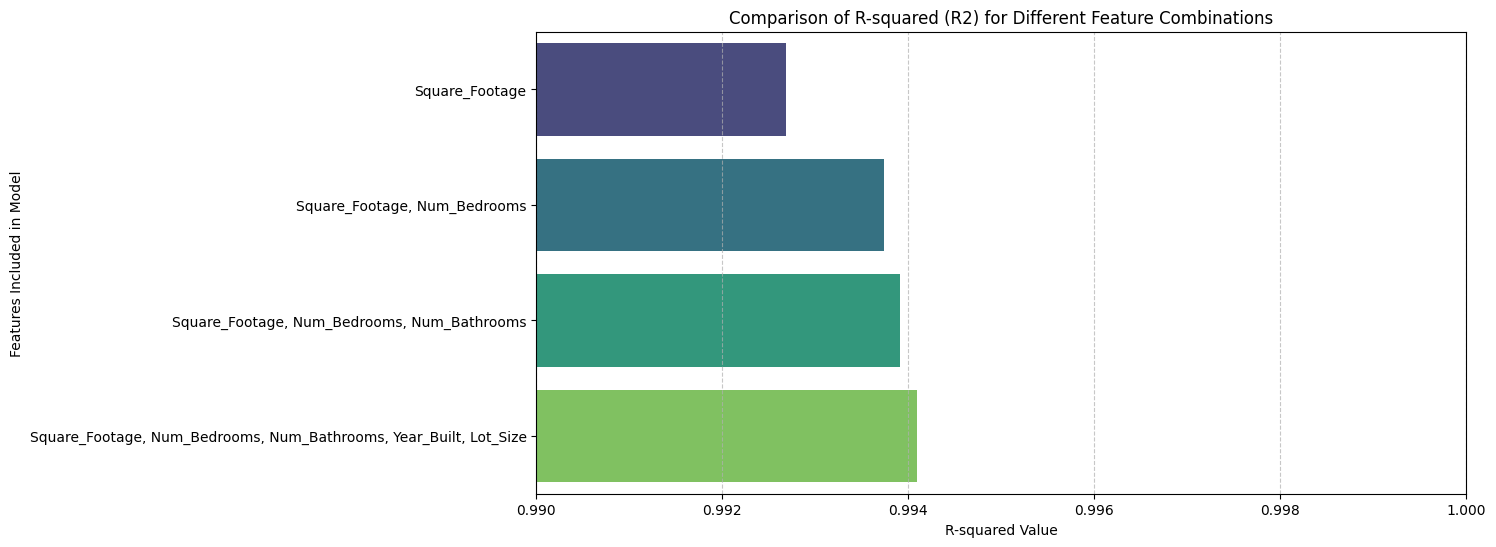

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Using the results_df generated in the previous step
results_df['Feature_Count'] = results_df['Features'].apply(len)
results_df['Feature_Names'] = results_df['Features'].apply(lambda x: ', '.join(x))

plt.figure(figsize=(12, 6))
sns.barplot(x='R2', y='Feature_Names', data=results_df, palette='viridis', hue='Feature_Names', legend=False)

plt.title('Comparison of R-squared (R2) for Different Feature Combinations')
plt.xlabel('R-squared Value')
plt.ylabel('Features Included in Model')
plt.xlim(0.99, 1.0)  # Zooming in to highlight the performance differences
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Summary
Based on the R-squared comparison:

All Features: The model including all variables ('Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size') has the best performance (~0.9941).
Primary Driver: Even with only 'Square_Footage', the model captures over 99.2% of the variance, showing it is the most significant predictor.
Incremental Gains: Adding bedrooms and bathrooms marginally increases the R2 value, indicating they provide additional but smaller predictive value compared to square footage.

# Reflective Summary: Property Price Prediction with PySpark

### 1. Feature Selection Choices
For this exercise, the primary goal was to predict property prices using available physical attributes. I selected **Square_Footage**, **Num_Bedrooms**, **Num_Bathrooms**, **Year_Built**, and **Lot_Size** as independent variables. These choices were based on standard real estate valuation logic where size and utility (rooms) are primary drivers of value, while age and land area provide secondary context.

### 2. Observations from Model Comparisons
By iterating through multiple feature combinations, several patterns emerged:
*   **Single-Variable Power:** The baseline model using only `Square_Footage` was remarkably strong, achieving an R-squared (~0.9927). This indicates the dataset likely has a high linear correlation between size and price.
*   **Diminishing Returns:** Adding `Num_Bedrooms` and `Num_Bathrooms` improved the model, but the incremental gain in R-squared was relatively small (from 0.9927 to 0.9939).
*   **Optimal Performance:** The full model (5 features) yielded the best results with an R2 of ~0.9941, suggesting that while square footage is the main driver, the other variables do contribute meaningful noise reduction and predictive accuracy.

### 3. Challenges and Resolutions
*   **Data Scale:** Handling 1,000,000 records can be taxing for standard pandas. By using **PySpark**, I leveraged distributed data processing to ensure that feature assembly, scaling, and model training remained performant.
*   **Feature Scaling:** Raw features like `Year_Built` (1900-2021) and `Square_Footage` (500-5000) have vastly different scales. I resolved potential model bias by implementing the `StandardScaler`, ensuring each feature contributed proportionately to the gradient descent process.

### 4. Insights Gained
*   **PySpark Workflow:** This exercise highlighted the structured nature of the PySpark ML API, specifically the necessity of the `VectorAssembler` to prepare data for estimators.
*   **Linearity:** The exceptionally high R-squared suggests the underlying data generation for this specific database is likely highly linear. In real-world scenarios, we might expect more variance, necessitating non-linear models or further feature engineering.
*   **Efficiency:** Using Spark's lazy evaluation and optimized execution plan allowed for rapid experimentation across different model configurations.